# Customer Segmentation and Revenue Intelligence

Customer persona analysis combining value, reliability, repeat behavior, booking horizon, and channel behavior.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
segments = pd.read_csv(ROOT / 'outputs/tables/customer_persona_segments.csv')
scorecard = pd.read_csv(ROOT / 'data/processed/customer_segment_performance.csv')
segments.head(12)

,country,market_segment,customer_type,bookings,cancellation_rate,realized_revenue,adr,average_lead_time,repeat_guest_rate,average_special_requests,average_total_nights,persona_cluster,persona_label,customer_value_score
0,GBR,Offline TA/TO,Contract,1293,0.000773,882124.96,77.556164,169.187935,0.009281,0.514308,8.823666,2,Long-lead cancellation watchlist,78.62
1,ESP,Direct,Transient,971,0.087539,368811.12,129.845551,37.198764,0.021627,0.622039,2.990731,0,Value-managed core guests,78.46
2,GBR,Offline TA/TO,Transient,1516,0.001979,685207.92,73.474156,114.514512,0.006596,0.411609,6.086412,2,Long-lead cancellation watchlist,76.91
3,FRA,Direct,Transient,914,0.094092,343714.63,121.710011,52.815098,0.017505,0.621444,3.391685,0,Value-managed core guests,75.81
4,PRT,Direct,Transient,5295,0.200567,1413926.31,110.718706,34.722191,0.103494,0.563362,2.750142,4,Niche loyalty opportunity,75.79
5,IRL,Offline TA/TO,Transient,394,0.000000,185083.59,69.325635,114.538071,0.007614,0.418782,6.535533,2,Long-lead cancellation watchlist,75.14
6,DEU,Offline TA/TO,Transient-Party,1308,0.000000,317826.71,100.420925,257.788226,0.000000,0.488532,2.496177,3,Premium reliable guests,74.27
7,FRA,Offline TA/TO,Transient,1343,0.002234,433529.27,79.884594,61.812360,0.001489,0.200298,4.109456,3,Premium reliable guests,73.46
8,GBR,Direct,Transient,764,0.108639,299447.24,112.823809,81.333770,0.032723,0.544503,4.049738,0,Value-managed core guests,73.23
9,GBR,Groups,Transient-Party,1322,0.009077,381725.97,67.410257,233.765507,0.006051,0.187595,4.493192,2,Long-lead cancellation watchlist,72.81


In [2]:
segments.groupby('persona_label').agg(
    segments=('persona_label', 'count'),
    bookings=('bookings', 'sum'),
    avg_cancel_rate=('cancellation_rate', 'mean'),
    revenue=('realized_revenue', 'sum'),
    avg_value_score=('customer_value_score', 'mean')
).sort_values('revenue', ascending=False)

,segments,bookings,avg_cancel_rate,revenue,avg_value_score
persona_label,,,,,
Niche loyalty opportunity,10,60988,0.490748,10112360.69,61.353000
Value-managed core guests,89,29311,0.244550,8154028.42,49.727753
Premium reliable guests,48,12214,0.047059,3046673.05,50.696250
Long-lead cancellation watchlist,22,7492,0.227096,2830809.50,50.329091
High-volume commercial demand,9,4199,0.171183,329971.97,41.111111


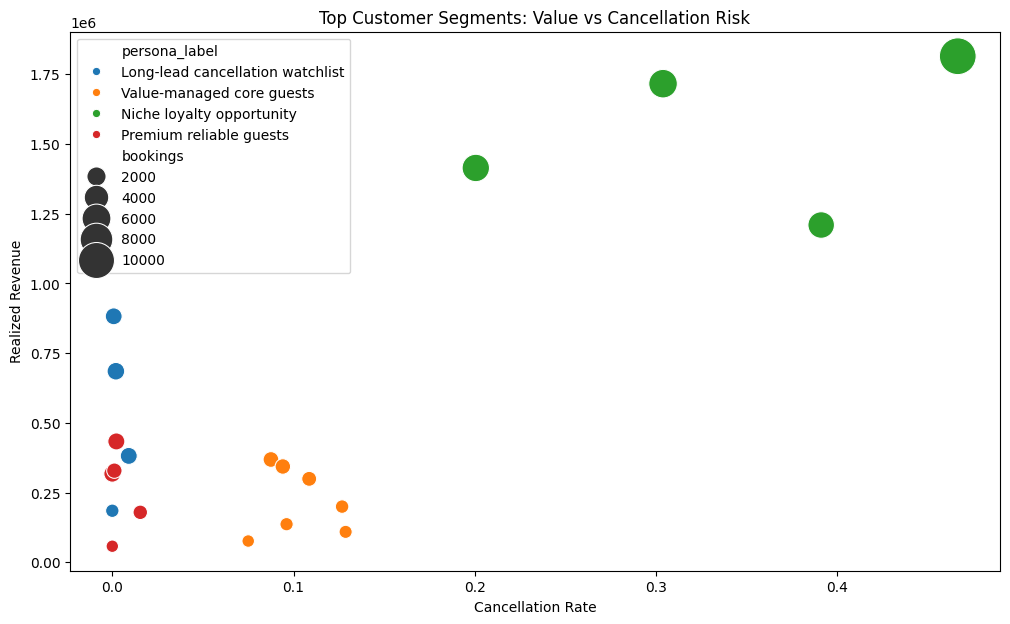

In [3]:
top = segments.head(20)
plt.figure(figsize=(12, 7))
sns.scatterplot(data=top, x='cancellation_rate', y='realized_revenue',
                size='bookings', hue='persona_label', sizes=(80, 700))
plt.title('Top Customer Segments: Value vs Cancellation Risk')
plt.xlabel('Cancellation Rate')
plt.ylabel('Realized Revenue')
plt.show()